In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/smagnan/1-million-reddit-comments-from-40-subreddits/kaggle_RC_2019-05.csv


In [2]:
import pandas as pd; 
df = pd.read_csv('/kaggle/input/datasets/smagnan/1-million-reddit-comments-from-40-subreddits/kaggle_RC_2019-05.csv')
df.head(20)
df.sample(20)

,subreddit,body,controversiality,score
724305,FortNiteBR,Well hopefully the skins return at the end of ...,0,3
587239,asoiaf,I mean I agree but the books would only be mad...,0,1
730120,funny,The unplanned pregnancy dude is the guy that’s...,0,5
736307,gonewild,Hope that didn’t ruin the vibe. Very sexy!,0,1
533388,pics,It's still a joke,0,-39
222059,gameofthrones,My two cents:\n\nThe whitewalkers - more or le...,0,1
373838,leagueoflegends,1.7 kills per minute lmfao,0,7
280391,unpopularopinion,The show's expressed opinions likely ring true...,1,-1
939473,ChapoTrapHouse,Thanks for the info; I stand corrected.,0,2
877605,leagueoflegends,Yea awhile back it was too long but it wasn’t ...,0,2


In [3]:
df.duplicated().sum()

np.int64(22011)

In [4]:
df = df.drop_duplicates()
print(df.shape)  # check new row count

(977989, 4)


In [5]:
print(df.columns.tolist())

['subreddit', 'body', 'controversiality', 'score']


In [6]:
df['subreddit'].str.len().describe()

count    977989.000000
mean          8.919520
std           3.965173
min           3.000000
25%           6.000000
50%           8.000000
75%          13.000000
max          19.000000
Name: subreddit, dtype: float64

In [7]:
df['body'].str.len().describe()

count    977989.000000
mean        158.421124
std         259.303086
min           7.000000
25%          42.000000
50%          79.000000
75%         167.000000
max       10106.000000
Name: body, dtype: float64

In [8]:
import re

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\U00002700-\U000027BF"  # dingbats
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U00002600-\U000026FF"  # misc symbols
    "\U0001FA70-\U0001FAFF"  # symbols extended-A
    "\U00002B00-\U00002BFF"  # misc symbols and arrows
    "\U0001F000-\U0001F02F"  # mahjong/dominoes (rare but exists)
    "]+", flags=re.UNICODE
)

df['body'] = df['body'].astype(str).apply(lambda x: emoji_pattern.sub('', x))

In [9]:
df.sample(20)

,subreddit,body,controversiality,score
538920,marvelstudios,"He has the reality stone though, he could just...",0,1
97655,ChapoTrapHouse,nice anime avatar in your profile kid\n\nopini...,0,-4
882128,FortNiteBR,"To clarify, you can find the same set pieces f...",0,2
133007,dankmemes,0.5 inches is 1.27 cm,0,0
733319,news,Or maybe its just a pyromaniac lunatic who tho...,0,1
920819,aww,He's a grumpy old man so any foreign object wi...,0,8
295660,gameofthrones,&gt; Another wilder theory is that he is Syrio...,0,3
646658,nfl,Depending on the real estate person/seller of ...,0,2
719971,movies,"God, the Dothraki charge annoyed me. Everyone ...",0,18
365191,wallstreetbets,you cheap fuck. who buys TCL,0,5


In [10]:
df.to_csv('cleaned_data.csv', index=False)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Basic shape and info
print("Shape:", df.shape)
print("\nColumn info:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (977989, 4)

Column info:
<class 'pandas.core.frame.DataFrame'>
Index: 977989 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   subreddit         977989 non-null  object
 1   body              977989 non-null  object
 2   controversiality  977989 non-null  int64 
 3   score             977989 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 37.3+ MB
None

Missing values per column:
subreddit           0
body                0
controversiality    0
score               0
dtype: int64

Duplicate rows: 30


In [12]:
# Text length on 'body' column
df['text_len'] = df['body'].str.len()
df['word_count'] = df['body'].str.split().str.len()

print(df['text_len'].describe())

count    977989.000000
mean        158.372314
std         259.076471
min           4.000000
25%          42.000000
50%          79.000000
75%         167.000000
max       10106.000000
Name: text_len, dtype: float64


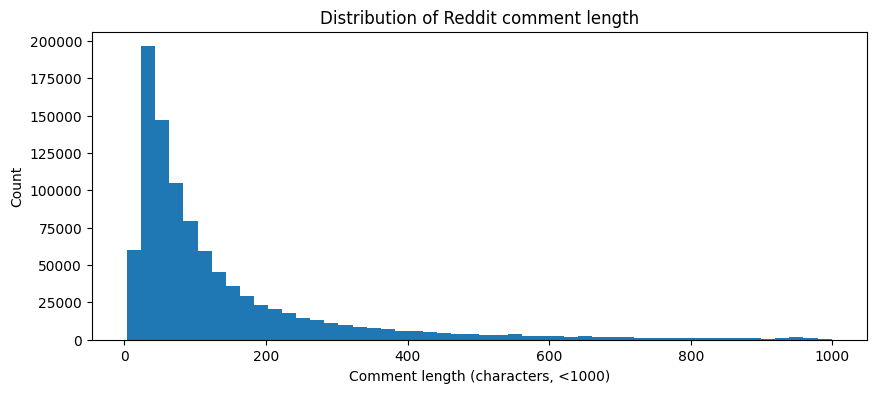

In [13]:
# Text length distribution (zoomed to avoid outlier squash)
plt.figure(figsize=(10, 4))
plt.hist(df[df['text_len'] < 1000]['text_len'], bins=50)
plt.xlabel('Comment length (characters, <1000)')
plt.ylabel('Count')
plt.title('Distribution of Reddit comment length')
plt.show()

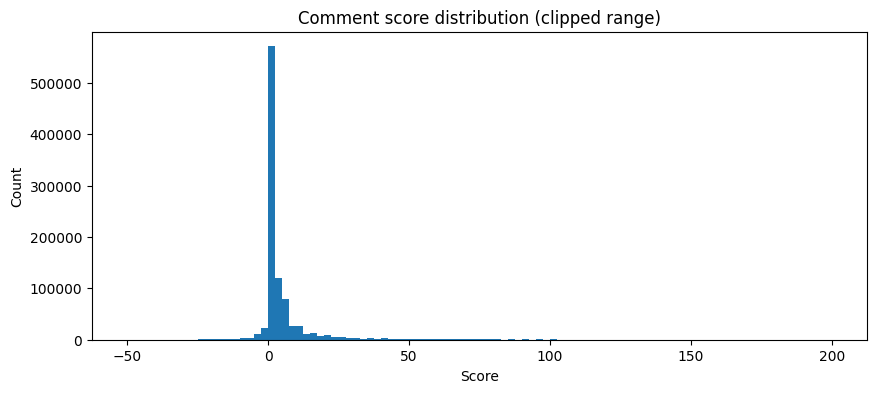

In [14]:
# Score distribution — heavily skewed usually, so log scale helps
plt.figure(figsize=(10, 4))
plt.hist(df['score'], bins=100, range=(-50, 200))
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Comment score distribution (clipped range)')
plt.show()

controversiality
0    948437
1     29552
Name: count, dtype: int64


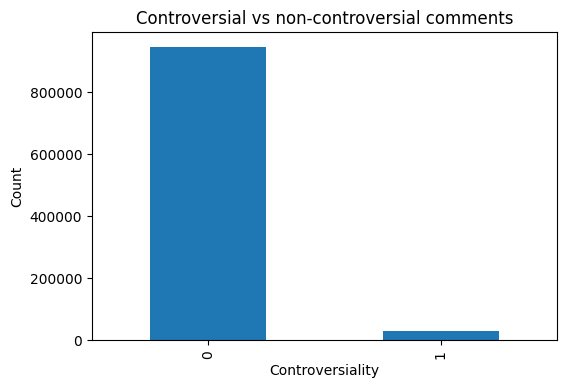

In [15]:
# Controversiality — likely mostly 0/1, check the split
print(df['controversiality'].value_counts())

df['controversiality'].value_counts().plot(kind='bar', figsize=(6,4))
plt.xlabel('Controversiality')
plt.ylabel('Count')
plt.title('Controversial vs non-controversial comments')
plt.show()

In [16]:
import pandas as pd
import numpy as np

# Basic features from what we already have
df['text_len'] = df['body'].str.len()
df['word_count'] = df['body'].str.split().str.len()
df['has_question'] = df['body'].str.contains(r'\?', regex=True, na=False).astype(int)
df['has_exclaim'] = df['body'].str.contains(r'!', regex=True, na=False).astype(int)
df['is_upper_ratio'] = df['body'].str.count(r'[A-Z]') / df['text_len'].replace(0, 1)

# Drop rows with missing target or body
df_model = df.dropna(subset=['controversiality', 'body']).copy()
print(df_model.shape)
print(df_model['controversiality'].value_counts())

(977989, 9)
controversiality
0    948437
1     29552
Name: count, dtype: int64


In [17]:
# Check the imbalance ratio
print(df_model['controversiality'].value_counts(normalize=True))

controversiality
0    0.969783
1    0.030217
Name: proportion, dtype: float64


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ['text_len', 'word_count', 'has_question', 'has_exclaim', 'is_upper_ratio', 'score']

X = df_model[feature_cols].fillna(0)
y = df_model['controversiality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.50      0.66    189688
           1       0.04      0.73      0.08      5910

    accuracy                           0.51    195598
   macro avg       0.51      0.61      0.37    195598
weighted avg       0.95      0.51      0.64    195598



In [20]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)
tree.fit(X_train, y_train)  # trees don't need scaling

y_pred_tree = tree.predict(X_test)
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.99      0.80      0.89    189688
           1       0.09      0.65      0.16      5910

    accuracy                           0.80    195598
   macro avg       0.54      0.73      0.52    195598
weighted avg       0.96      0.80      0.86    195598



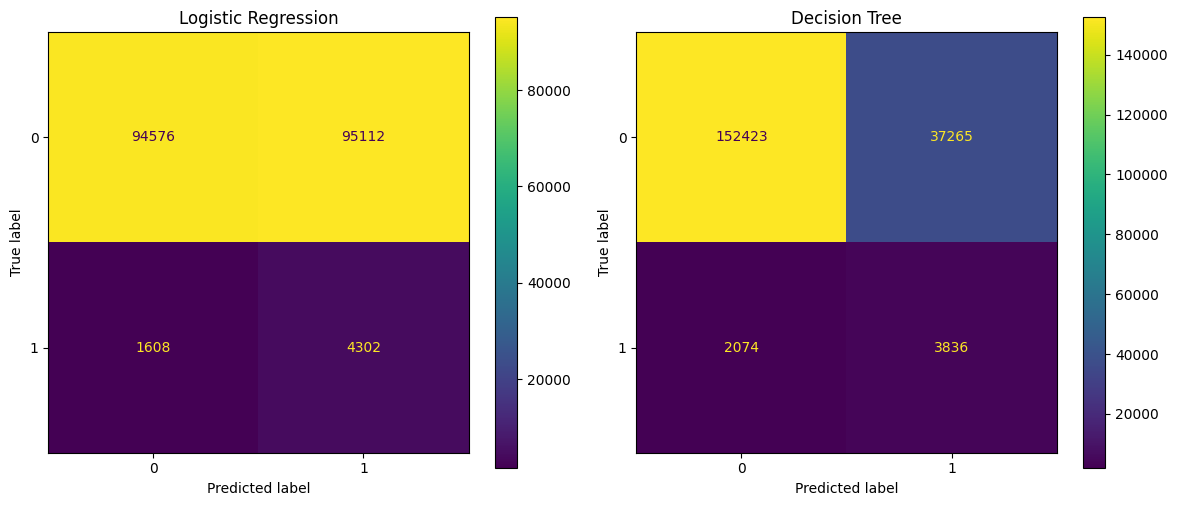

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=axes[1])
axes[1].set_title('Decision Tree')
plt.tight_layout()
plt.show()

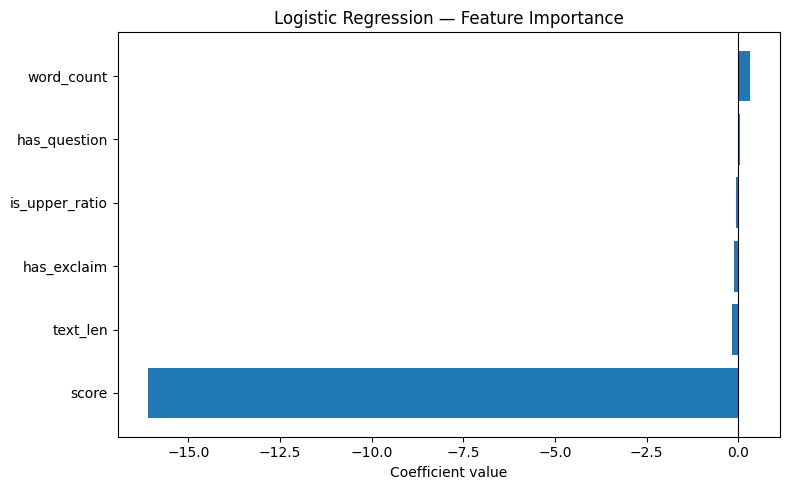

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Feature importance from Logistic Regression (coefficients)
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient')

plt.figure(figsize=(8, 5))
plt.barh(coef_df['feature'], coef_df['coefficient'])
plt.xlabel('Coefficient value')
plt.title('Logistic Regression — Feature Importance')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

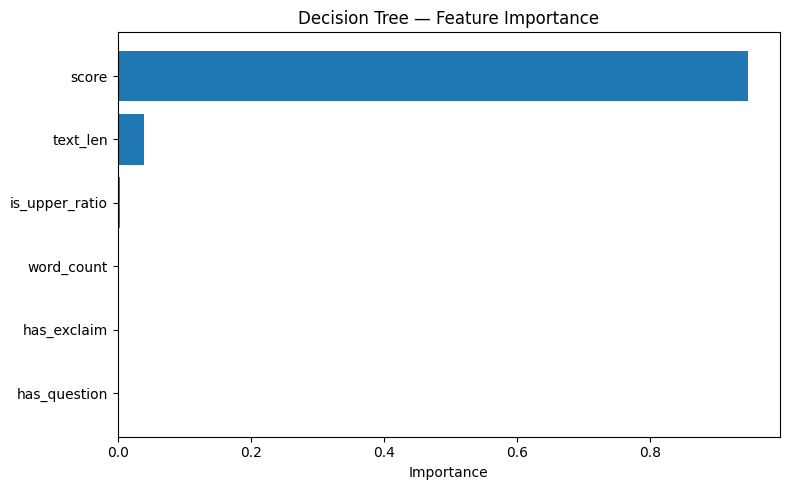

In [23]:
# 2. Feature importance from Decision Tree
tree_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': tree.feature_importances_
}).sort_values('importance')

plt.figure(figsize=(8, 5))
plt.barh(tree_importance['feature'], tree_importance['importance'])
plt.xlabel('Importance')
plt.title('Decision Tree — Feature Importance')
plt.tight_layout()
plt.show()

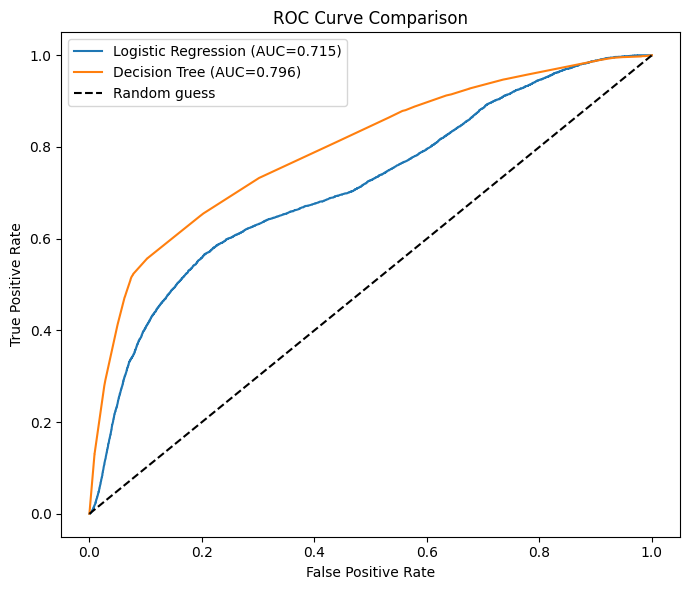

In [24]:
# 3. ROC curves for both models — great for comparing at a glance
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_tree = tree.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

plt.figure(figsize=(7, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_log):.3f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC={roc_auc_score(y_test, y_prob_tree):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

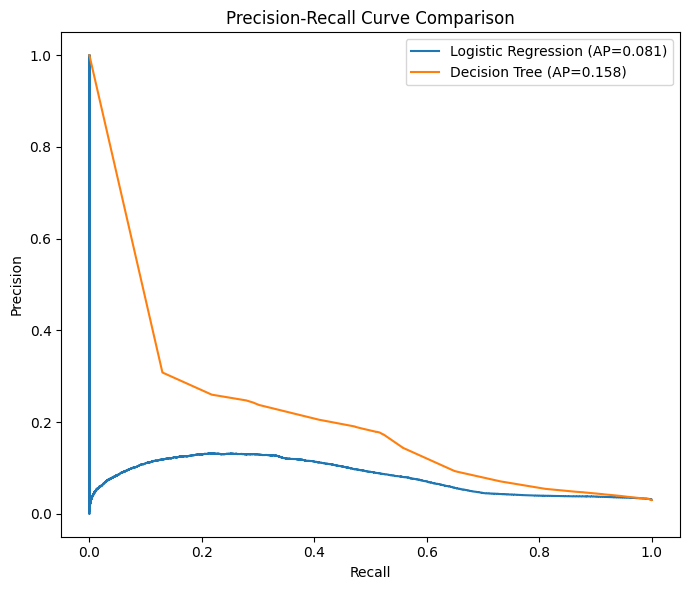

In [25]:
# 4. Precision-Recall curves — more informative than ROC for imbalanced classes like this
from sklearn.metrics import precision_recall_curve, average_precision_score

prec_log, rec_log, _ = precision_recall_curve(y_test, y_prob_log)
prec_tree, rec_tree, _ = precision_recall_curve(y_test, y_prob_tree)

plt.figure(figsize=(7, 6))
plt.plot(rec_log, prec_log, label=f'Logistic Regression (AP={average_precision_score(y_test, y_prob_log):.3f})')
plt.plot(rec_tree, prec_tree, label=f'Decision Tree (AP={average_precision_score(y_test, y_prob_tree):.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

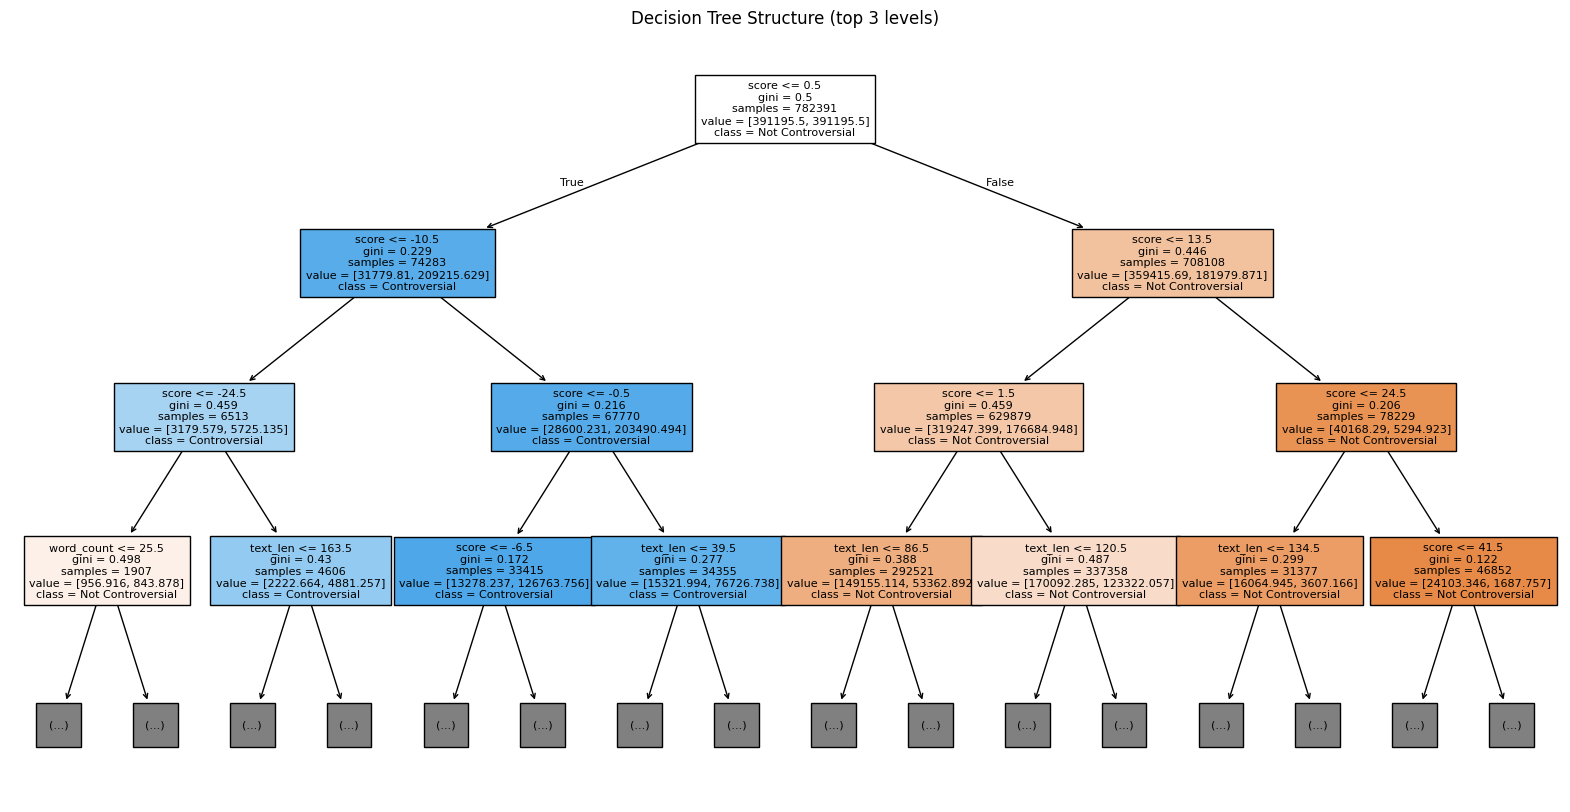

In [26]:
# 5. Decision tree structure (small depth, so it's actually readable)
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=feature_cols, class_names=['Not Controversial', 'Controversial'],
          filled=True, max_depth=3, fontsize=8)
plt.title('Decision Tree Structure (top 3 levels)')
plt.show()

if someone asks "how good is your baseline," the honest answer uses F1 or PR AUC, not accuracy — and given how simple your features are (length, punctuation counts), don't be surprised if both scores are pretty low. That's the expected, realistic outcome of a first baseline.

In [27]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

def evaluate(y_true, y_pred, y_prob, model_name):
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}  (misleading here — see note below)")
    print(f"F1 score:  {f1_score(y_true, y_pred):.3f}")
    print(f"ROC AUC:   {roc_auc_score(y_true, y_prob):.3f}")
    print(f"PR AUC:    {average_precision_score(y_true, y_prob):.3f}  <- most informative for imbalanced data")
    print()

evaluate(y_test, y_pred, y_prob_log, "Logistic Regression")
evaluate(y_test, y_pred_tree, y_prob_tree, "Decision Tree")

--- Logistic Regression ---
Accuracy:  0.506  (misleading here — see note below)
F1 score:  0.082
ROC AUC:   0.715
PR AUC:    0.081  <- most informative for imbalanced data

--- Decision Tree ---
Accuracy:  0.799  (misleading here — see note below)
F1 score:  0.163
ROC AUC:   0.796
PR AUC:    0.158  <- most informative for imbalanced data



doing tf idf model to check if we get better accuracy and a good model

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Re-split using the raw text this time
X_text = df_model['body']
y = df_model['controversiality']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=5000,      # limit vocab size to keep it fast
    stop_words='english',
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=5                # ignore very rare terms
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(X_train_tfidf.shape)

(782391, 5000)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

log_reg_tfidf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = log_reg_tfidf.predict(X_test_tfidf)
y_prob_tfidf = log_reg_tfidf.predict_proba(X_test_tfidf)[:, 1]

print(f"F1 score:  {f1_score(y_test, y_pred_tfidf):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob_tfidf):.3f}")
print(f"PR AUC:    {average_precision_score(y_test, y_prob_tfidf):.3f}")

F1 score:  0.098
ROC AUC:   0.680
PR AUC:    0.065


In [30]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression (features)', 'Decision Tree (features)', 'Logistic Regression (TF-IDF text)'],
    'F1': [f1_score(y_test, y_pred), f1_score(y_test, y_pred_tree), f1_score(y_test, y_pred_tfidf)],
    'ROC AUC': [roc_auc_score(y_test, y_prob_log), roc_auc_score(y_test, y_prob_tree), roc_auc_score(y_test, y_prob_tfidf)],
    'PR AUC': [average_precision_score(y_test, y_prob_log), average_precision_score(y_test, y_prob_tree), average_precision_score(y_test, y_prob_tfidf)]
})
print(results)

                               Model        F1   ROC AUC    PR AUC
0     Logistic Regression (features)  0.081691  0.714664  0.081201
1           Decision Tree (features)  0.163196  0.795723  0.158356
2  Logistic Regression (TF-IDF text)  0.098274  0.679667  0.064908


In [31]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
coefs = log_reg_tfidf.coef_[0]

top_pos_idx = np.argsort(coefs)[-15:]
top_neg_idx = np.argsort(coefs)[:15]

print("Top words pushing toward CONTROVERSIAL:")
for i in reversed(top_pos_idx):
    print(f"  {feature_names[i]}: {coefs[i]:.3f}")

print("\nTop words pushing toward NOT controversial:")
for i in top_neg_idx:
    print(f"  {feature_names[i]}: {coefs[i]:.3f}")

Top words pushing toward CONTROVERSIAL:
  night king: 3.730
  barca: 3.213
  kill nk: 3.208
  socialism: 3.129
  esh: 3.080
  downvotes: 3.056
  mueller said: 3.024
  suspension: 2.970
  aew: 2.884
  dive: 2.850
  downvoted: 2.842
  liverpool: 2.831
  godswood: 2.766
  right wing: 2.600
  downvote: 2.588

Top words pushing toward NOT controversial:
  ign: -4.330
  lvl: -4.005
  них: -3.648
  market76: -3.605
  psn: -3.514
  privacy: -3.471
  driver: -3.468
  sauce: -3.464
  shrimp: -3.458
  ups: -3.421
  tse: -3.412
  submission: -3.385
  pad: -3.340
  bobby: -3.339
  euron: -3.302


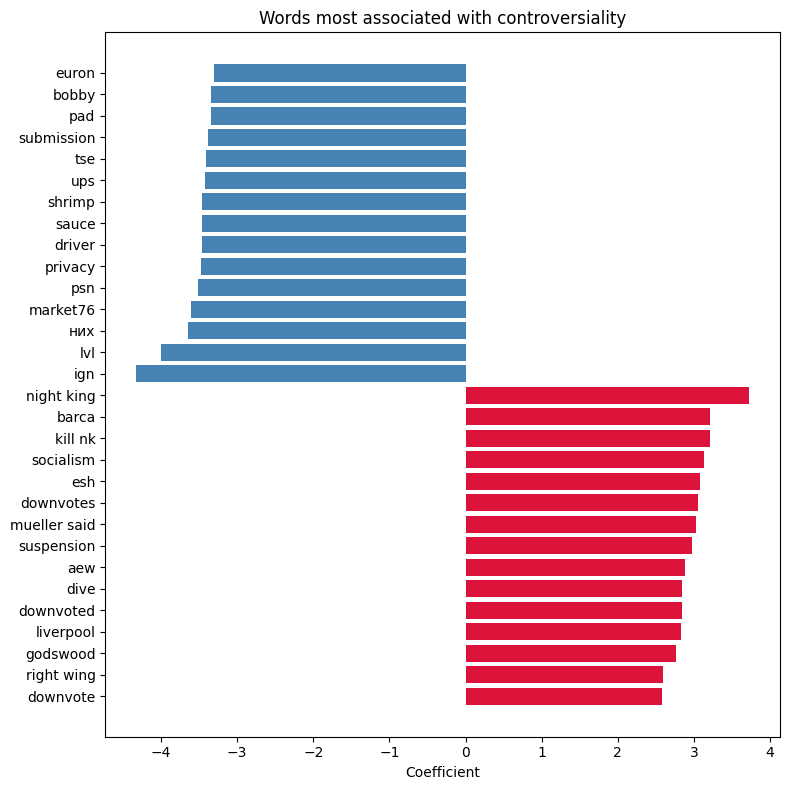

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.barh(feature_names[top_pos_idx], coefs[top_pos_idx], color='crimson')
plt.barh(feature_names[top_neg_idx], coefs[top_neg_idx], color='steelblue')
plt.xlabel('Coefficient')
plt.title('Words most associated with controversiality')
plt.tight_layout()
plt.show()

well it didnt help 

In [33]:
!pip install xgboost -q

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# --- 1. Feature engineering (structural features) ---
df['text_len'] = df['body'].str.len()
df['word_count'] = df['body'].str.split().str.len()
df['has_question'] = df['body'].str.contains(r'\?', regex=True, na=False).astype(int)
df['has_exclaim'] = df['body'].str.contains(r'!', regex=True, na=False).astype(int)
df['is_upper_ratio'] = df['body'].str.count(r'[A-Z]') / df['text_len'].replace(0, 1)

df_model = df.dropna(subset=['controversiality', 'body']).copy()

feature_cols = ['text_len', 'word_count', 'has_question', 'has_exclaim', 'is_upper_ratio', 'score']
X = df_model[feature_cols].fillna(0)
y = df_model['controversiality']

# --- 2. Structural feature train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3. Text train/test split (same rows, same random_state = aligned) ---
X_text = df_model['body']
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. TF-IDF ---
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2), min_df=5)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("All variables rebuilt.")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_train_tfidf:", X_train_tfidf.shape)

All variables rebuilt.
X_train: (782391, 6) | y_train: (782391,)
X_train_tfidf: (782391, 5000)


In [35]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

# Handle imbalance
neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# --- XGBoost on structural features ---
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("--- XGBoost (structural features) ---")
print(f"F1 score:  {f1_score(y_test, y_pred_xgb):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob_xgb):.3f}")
print(f"PR AUC:    {average_precision_score(y_test, y_prob_xgb):.3f}")

scale_pos_weight: 32.09
--- XGBoost (structural features) ---
F1 score:  0.185
ROC AUC:   0.803
PR AUC:    0.171


xgboost is the best model so far with the highest score

In [36]:
!pip install textblob -q

           sentiment  all_caps_words
count  977989.000000   977989.000000
mean        0.068345        0.374027
std         0.278215        1.773964
min        -1.000000        0.000000
25%         0.000000        0.000000
50%         0.000000        0.000000
75%         0.200000        0.000000
max         1.000000      338.000000
--- XGBoost (features + subreddit + sentiment) ---
F1 score:  0.185
ROC AUC:   0.841
PR AUC:    0.191


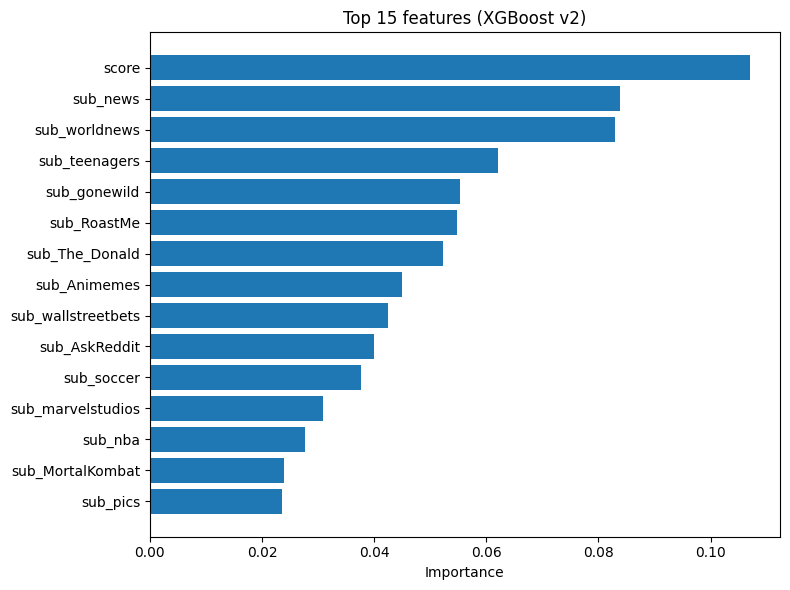

In [37]:
from textblob import TextBlob

# --- New feature 1: subreddit (one-hot encode top N, group rest as 'other') ---
top_subs = df_model['subreddit'].value_counts().head(30).index
df_model['subreddit_grouped'] = df_model['subreddit'].apply(lambda x: x if x in top_subs else 'other')
subreddit_dummies = pd.get_dummies(df_model['subreddit_grouped'], prefix='sub')

# --- New feature 2: sentiment polarity ---
# NOTE: this can be slow on large datasets — consider sampling first if it takes too long
df_model['sentiment'] = df_model['body'].apply(lambda x: TextBlob(x).sentiment.polarity)

# --- New feature 3: all-caps word count (distinct from uppercase char ratio) ---
df_model['all_caps_words'] = df_model['body'].apply(
    lambda x: sum(1 for w in x.split() if w.isupper() and len(w) > 1)
)

print(df_model[['sentiment', 'all_caps_words']].describe())

feature_cols_v2 = ['text_len', 'word_count', 'has_question', 'has_exclaim',
                    'is_upper_ratio', 'score', 'sentiment', 'all_caps_words']

X_v2 = pd.concat([df_model[feature_cols_v2].fillna(0).reset_index(drop=True),
                   subreddit_dummies.reset_index(drop=True)], axis=1)
y_v2 = df_model['controversiality'].reset_index(drop=True)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

neg, pos = y_train_v2.value_counts()
scale_pos_weight_v2 = neg / pos

xgb_v2 = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_v2, eval_metric='logloss', random_state=42
)
xgb_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = xgb_v2.predict(X_test_v2)
y_prob_v2 = xgb_v2.predict_proba(X_test_v2)[:, 1]

print("--- XGBoost (features + subreddit + sentiment) ---")
print(f"F1 score:  {f1_score(y_test_v2, y_pred_v2):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test_v2, y_prob_v2):.3f}")
print(f"PR AUC:    {average_precision_score(y_test_v2, y_prob_v2):.3f}")

importance_df = pd.DataFrame({
    'feature': X_v2.columns,
    'importance': xgb_v2.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 15 features (XGBoost v2)')
plt.tight_layout()
plt.show()

wozie now thats cool